# Illustration Exercise — Credit Risk

## Context

The ROC (Receiver Operating Characteristic) curve plots the True Positive Rate
(TPR) against the False Positive Rate (FPR) as the classification threshold
varies from 1 to 0. AUROC (Area Under the ROC Curve) summarises discrimination
in a single number: 0.5 is random, 1.0 is perfect. The KS (Kolmogorov–Smirnov)
statistic is the maximum vertical distance between the ROC curve and the
45-degree diagonal. This exercise trains a logistic regression on the UCI
German Credit dataset — 1,000 loan applicants classified as good or bad credit
risk — and visualises both metrics on the ROC curve.

## Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import requests
import pathlib, warnings
warnings.filterwarnings("ignore")
from io import StringIO
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

plt.style.use(["science", "no-latex"])

# Download UCI Statlog German Credit dataset
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
       "/statlog/german/german.data")
resp = requests.get(url, timeout=20)
df = pd.read_csv(StringIO(resp.text), sep=" ", header=None)

# Target: column 20  (1 = good credit, 2 = bad credit) -> 0 / 1
y = (df.iloc[:, 20] == 2).astype(int).values

# Numeric feature columns (duration, amount, installment rate, age,
# num existing credits, num liable people)
numeric_cols = [1, 4, 7, 10, 12, 15]
X = df.iloc[:, numeric_cols].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train, y_train)
y_prob = clf.predict_proba(X_test)[:, 1]

print(f"Test set: {len(y_test)} samples  |  "
      f"Default rate: {y_test.mean():.1%}")

Test set: 300 samples  |  Default rate: 30.0%


## Figure

Saved to C:\Users\jfimb\Documents\book-course-template\book\chapters\06-credit-risk\figures\fig_illustration.pdf


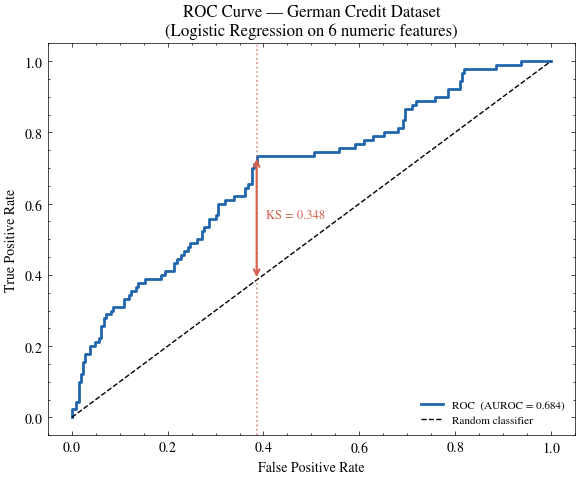

AUROC = 0.6837  |  KS = 0.3476  |  Gini = 0.3673


In [2]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auroc = roc_auc_score(y_test, y_prob)

# KS statistic: max separation between TPR and FPR
ks_idx  = np.argmax(tpr - fpr)
ks_stat = (tpr - fpr)[ks_idx]
ks_fpr  = fpr[ks_idx]
ks_tpr  = tpr[ks_idx]

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#2166ac", lw=2, label=f"ROC  (AUROC = {auroc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")

# KS annotation
ax.annotate("", xy=(ks_fpr, ks_tpr), xytext=(ks_fpr, ks_fpr),
            arrowprops=dict(arrowstyle="<->", color="#d6604d", lw=1.5))
ax.annotate(f"KS = {ks_stat:.3f}",
            xy=(ks_fpr + 0.02, (ks_tpr + ks_fpr) / 2),
            fontsize=9, color="#d6604d")
ax.axvline(ks_fpr, color="#d6604d", linestyle=":", lw=1.2, alpha=0.7)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — German Credit Dataset\n"
             "(Logistic Regression on 6 numeric features)")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()

out_path = pathlib.Path(
    "../../../book/chapters/06-credit-risk/figures/fig_illustration.pdf"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved to {out_path.resolve()}")
plt.show()
print(f"AUROC = {auroc:.4f}  |  KS = {ks_stat:.4f}  |  "
      f"Gini = {2*auroc-1:.4f}")

## Your Turn

Encode all 20 features (not just the 6 numeric ones) by one-hot encoding the
categorical columns. Retrain the logistic regression and compare the new AUROC
and KS statistic to the baseline above. Does adding categorical features improve
discrimination? Which feature category (using `sklearn`'s `coef_` attribute)
has the largest absolute weight in the fitted model?

# Chapter 6 — Exercises: LLMs for Credit Risk Analysis

This notebook contains starter code for the exercises in Chapter 6 of *Large Language Models in Finance*.

**Exercises:**
- [B] Calibrating implied default probabilities from structured LLM generation
- [I] Persona agents for mortgage product choice simulation
- [A] End-to-end credit risk pipeline with SR 11-7 documentation

[Placeholder — fill in with exercise starter code when drafting the chapter]